# Tech Pulse v3 — Advanced Framework

Loads precomputed signals from GitHub (saved by v2 Section 22) and runs:

1. **S&P 500 benchmark** — compare all strategies against SPY
2. **Asymmetric sentiment** — per-ticker positive/negative weighting
3. **Refined sectors** — split Fintech/Crypto, add Cybersecurity, Semiconductor Supply Chain
4. **Sector quality weighting** — allocate more to high-quality sectors
5. **Cross-company spillover signals** — wire confirmed pairs into strategy
6. **Combined strategy** — sector rotation + weighted position entry + spillover

**Prerequisite:** Run Section 22 of `tech_pulse_v2.ipynb` first.

---
## 0. Install

In [1]:
# !pip install pandas requests python-dotenv matplotlib seaborn scipy

---
## 1. Configuration & Load

In [2]:
import os, io, requests, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from datetime import datetime, timezone
from dotenv import load_dotenv
load_dotenv()

GITHUB_REPO    = 'annhmartin/dataviz-historical-stocks-AnnetteMartin'
GITHUB_TOKEN   = os.environ.get('GITHUB_TOKEN', None)
OUTPUT_PREFIX  = 'tech_pulse_outputs'
STOCKS_PREFIX  = 'stocks'
SENTIMENT_THRESHOLD = 0.05
ZSCORE_THRESHOLD    = 2.0

# Asymmetric sentiment weights (from v2 finding: 19/24 tickers respond more to positive)
POSITIVE_WEIGHT = 1.5
NEGATIVE_WEIGHT = 0.6

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#cccccc', 'axes.grid': True,
    'grid.color': '#e8e8e8', 'grid.linewidth': 0.7,
    'axes.spines.top': False, 'axes.spines.right': False,
})

def load_output(filename, token=None):
    url = f'https://raw.githubusercontent.com/{GITHUB_REPO}/main/{OUTPUT_PREFIX}/{filename}'
    headers = {'Authorization': f'Bearer {token}'} if token else {}
    resp = requests.get(url, headers=headers, timeout=60)
    if resp.status_code == 404:
        raise FileNotFoundError(f'{filename} not found — run Section 22 of v2 first')
    resp.raise_for_status()
    return pd.read_csv(io.StringIO(resp.text.strip()), low_memory=False)

def load_stock(ticker, token=None):
    url = f'https://raw.githubusercontent.com/{GITHUB_REPO}/main/{STOCKS_PREFIX}/prices_{ticker}.csv'
    headers = {'Authorization': f'Bearer {token}'} if token else {}
    resp = requests.get(url, headers=headers, timeout=60)
    if resp.status_code == 404: raise FileNotFoundError(ticker)
    resp.raise_for_status()
    df = pd.read_csv(io.StringIO(resp.text.strip()), low_memory=False)
    df['Date'] = pd.to_datetime(df['Date'])
    df['daily_return'] = df['Close'].pct_change(fill_method=None)
    return df.sort_values('Date').reset_index(drop=True)

print('Loading precomputed outputs ...')
daily_signals   = load_output('daily_signals.csv',   GITHUB_TOKEN)
df_prices       = load_output('df_prices.csv',       GITHUB_TOKEN)
best_per_ticker = load_output('best_per_ticker.csv', GITHUB_TOKEN)
df_corr         = load_output('df_corr.csv',         GITHUB_TOKEN)
df_company_map  = load_output('company_map.csv',     GITHUB_TOKEN)

# Load SPY benchmark
try:
    df_spy = load_stock('SPY', GITHUB_TOKEN)
    df_spy = df_spy.set_index('Date').sort_index()
    SPY_AVAILABLE = True
    print(f'SPY: {len(df_spy):,} rows ({df_spy.index.min().date()} to {df_spy.index.max().date()})')
except FileNotFoundError:
    SPY_AVAILABLE = False
    print('SPY not found — fetch with yfinance and add to stocks/ folder')

# Rebuild COMPANY_MAP
COMPANY_MAP = {
    row['ticker']: {'names': row['names'].split('|'), 'keywords': row['keywords'].split('|')}
    for _, row in df_company_map.iterrows()
}
daily_signals['date'] = pd.to_datetime(daily_signals['date'])
df_prices['Date']     = pd.to_datetime(df_prices['Date'])
all_tickers = daily_signals['ticker'].unique().tolist()
top5 = best_per_ticker.head(5)['ticker'].tolist()

print(f'Loaded: {len(daily_signals):,} signal rows, {len(df_prices):,} price rows')
print(f'Tickers: {len(all_tickers)} | Top 5: {top5}')

Loading precomputed outputs ...
SPY not found — fetch with yfinance and add to stocks/ folder
Loaded: 121,771 signal rows, 81,953 price rows
Tickers: 29 | Top 5: ['PANW', 'NVO', 'CRWD', 'PLTR', 'PM']


---
## 2. Fetch SPY if Not Already in GitHub

Run this only if SPY showed 'not found' above.

In [3]:
if not SPY_AVAILABLE:
    try:
        import yfinance as yf
        import base64, io

        print('Fetching SPY from Yahoo Finance ...')
        df_spy_raw = yf.download('SPY', start='2010-01-01', progress=False, auto_adjust=True)
        if isinstance(df_spy_raw.columns, pd.MultiIndex):
            df_spy_raw.columns = df_spy_raw.columns.get_level_values(0)
        df_spy_raw = df_spy_raw.reset_index()
        df_spy_raw['ticker'] = 'SPY'

        # Push to GitHub
        buf = io.StringIO()
        df_spy_raw.to_csv(buf, index=False)
        encoded = base64.b64encode(buf.getvalue().encode()).decode()
        url = f'https://api.github.com/repos/{GITHUB_REPO}/contents/{STOCKS_PREFIX}/prices_SPY.csv'
        headers = {
            'Authorization': f'Bearer {GITHUB_TOKEN}',
            'Accept': 'application/vnd.github+json',
            'X-GitHub-Api-Version': '2022-11-28',
        }
        check = requests.get(url, headers=headers, timeout=15)
        sha = check.json().get('sha') if check.status_code == 200 else None
        payload = {'message': f'Add SPY prices ({len(df_spy_raw):,} rows)', 'content': encoded}
        if sha: payload['sha'] = sha
        resp = requests.put(url, headers=headers, json=payload, timeout=60)
        print(f'SPY pushed: {resp.status_code} | {len(df_spy_raw):,} rows')

        df_spy = df_spy_raw.set_index('Date').sort_index()
        df_spy['daily_return'] = df_spy['Close'].pct_change(fill_method=None)
        SPY_AVAILABLE = True
    except ImportError:
        print('yfinance not installed: !pip install yfinance')
else:
    print('SPY already loaded')

Fetching SPY from Yahoo Finance ...
SPY pushed: 201 | 4,149 rows


---
## 3. Refined Sector Map

Based on v2 findings:
- **Fintech/Crypto split** — COIN + TSLA behave as macro risk instruments; PYPL is enterprise fintech
- **Cybersecurity** split out from Cloud/SaaS — CRWD and PANW move together on threat news
- **Semiconductor Supply Chain** split from AI Accelerators — TSM/INTC/QCOM respond to fab news, not GPU demand
- **Big Tech** kept but AMZN moved closer to Cloud (AWS overlap)

Each sector also has a `quality_weight` — sectors that scored higher on buzz-to-return
correlation in v2 get more allocation weight.

In [4]:
SECTORS = {
    'AI Accelerators'       : ['NVDA', 'AMD'],
    'Semiconductor Supply'  : ['TSM', 'INTC', 'QCOM'],
    'Big Tech'              : ['GOOGL', 'MSFT', 'AAPL', 'META'],
    'Cloud / SaaS'          : ['AMZN', 'SNOW', 'DDOG', 'CRM', 'NOW', 'MDB'],
    'Cybersecurity'         : ['CRWD', 'PANW', 'OKTA'],
    'Enterprise AI'         : ['PLTR', 'TSLA'],
    'Enterprise Fintech'    : ['PYPL', 'CRM'],
    'Macro Risk'            : ['COIN', 'TSLA'],
    'Portfolio'             : ['INCY', 'KGC', 'NVO', 'PM', 'WPM'],
    'Consumer Tech'         : ['NFLX', 'SPOT', 'PINS'],
}

# Quality weights based on v2 sector quality analysis
# Higher = sector buzz more reliably predicts returns
SECTOR_QUALITY = {
    'AI Accelerators'       : 1.4,
    'Semiconductor Supply'  : 1.2,
    'Big Tech'              : 1.3,
    'Cloud / SaaS'          : 1.1,
    'Cybersecurity'         : 1.2,
    'Enterprise AI'         : 1.0,
    'Enterprise Fintech'    : 0.7,   # low quality from v2
    'Macro Risk'            : 0.6,   # COIN/PYPL don't correlate
    'Portfolio'             : 0.9,
    'Consumer Tech'         : 0.8,
}

SECTOR_COLORS = {
    'AI Accelerators'       : '#8e44ad',
    'Semiconductor Supply'  : '#6c3483',
    'Big Tech'              : '#2980b9',
    'Cloud / SaaS'          : '#27ae60',
    'Cybersecurity'         : '#e74c3c',
    'Enterprise AI'         : '#e67e22',
    'Enterprise Fintech'    : '#f39c12',
    'Macro Risk'            : '#95a5a6',
    'Portfolio'             : '#1abc9c',
    'Consumer Tech'         : '#3498db',
}

print(f'Refined sector map: {len(SECTORS)} sectors')
for sector, tickers in SECTORS.items():
    available = [t for t in tickers if t in all_tickers]
    q = SECTOR_QUALITY[sector]
    print(f'  {sector:<25} {tickers} | quality={q} | {len(available)}/{len(tickers)} in data')

Refined sector map: 10 sectors
  AI Accelerators           ['NVDA', 'AMD'] | quality=1.4 | 2/2 in data
  Semiconductor Supply      ['TSM', 'INTC', 'QCOM'] | quality=1.2 | 3/3 in data
  Big Tech                  ['GOOGL', 'MSFT', 'AAPL', 'META'] | quality=1.3 | 4/4 in data
  Cloud / SaaS              ['AMZN', 'SNOW', 'DDOG', 'CRM', 'NOW', 'MDB'] | quality=1.1 | 6/6 in data
  Cybersecurity             ['CRWD', 'PANW', 'OKTA'] | quality=1.2 | 3/3 in data
  Enterprise AI             ['PLTR', 'TSLA'] | quality=1.0 | 2/2 in data
  Enterprise Fintech        ['PYPL', 'CRM'] | quality=0.7 | 2/2 in data
  Macro Risk                ['COIN', 'TSLA'] | quality=0.6 | 2/2 in data
  Portfolio                 ['INCY', 'KGC', 'NVO', 'PM', 'WPM'] | quality=0.9 | 5/5 in data
  Consumer Tech             ['NFLX', 'SPOT', 'PINS'] | quality=0.8 | 2/3 in data


---
## 4. Per-Ticker Directional Strategy

From v2 Section 3: 19/24 tickers respond more to positive buzz, but 5 tickers
(COIN, MDB, NVO and others) had stronger negative buzz signals.

This section assigns each ticker its optimal signal direction,
then applies asymmetric weighting before building the combined strategy.

Computing per-ticker directional signal quality ...
Positive-primary tickers: 18
Negative-primary tickers: 6

ticker primary_signal  pos_win_rate  neg_win_rate  advantage
  CRWD       positive         0.818         0.059      0.759
  COIN       negative         0.170         0.778      0.609
  PLTR       positive         0.786         0.306      0.479
  OKTA       positive         0.663         0.349      0.314
  MSFT       positive         0.658         0.366      0.292
  AMZN       positive         0.642         0.356      0.286
  NVDA       positive         0.660         0.375      0.285
 GOOGL       positive         0.645         0.367      0.277
   MDB       negative         0.312         0.588      0.277
    PM       positive         0.600         0.326      0.274
   NOW       positive         0.604         0.372      0.232
  META       positive         0.631         0.405      0.226
  AAPL       positive         0.608         0.383      0.224
  NFLX       positive         0.618 

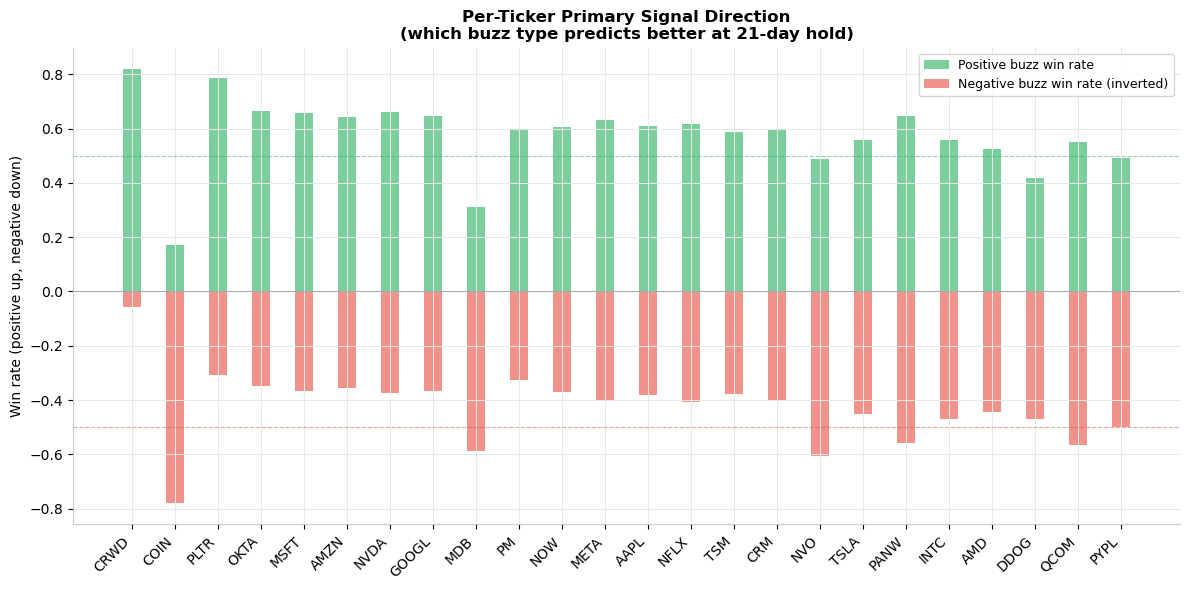

In [5]:
print('Computing per-ticker directional signal quality ...')

ticker_direction = {}
dir_results = []

for ticker in all_tickers:
    sig   = daily_signals[daily_signals['ticker']==ticker].copy()
    price = df_prices[df_prices['ticker']==ticker].copy()
    if sig.empty or price.empty: continue

    price = price.set_index('Date').sort_index()
    sig   = sig.set_index('date').sort_index()

    results = {}
    for direction in ['positive', 'negative']:
        mask = (sig['norm_sentiment'] >= SENTIMENT_THRESHOLD if direction == 'positive'
                else sig['norm_sentiment'] <= -SENTIMENT_THRESHOLD)
        sent_days = sig[mask]
        if len(sent_days) < 5: continue

        rets = []
        for date, _ in sent_days.iterrows():
            future = price.index[price.index > date]
            if len(future) < 21: continue
            entry = price.loc[future[0], 'Close']
            exit_ = price.loc[future[20], 'Close']
            ret   = (exit_ - entry) / entry * 100
            rets.append(ret)
        if not rets: continue
        rets = np.array(rets)
        win_rate = (rets > 0).mean() if direction == 'positive' else (rets < 0).mean()
        results[direction] = {'win_rate': win_rate, 'avg_ret': rets.mean(), 'n': len(rets)}

    if results:
        pos_wr = results.get('positive', {}).get('win_rate', 0)
        neg_wr = results.get('negative', {}).get('win_rate', 0)
        primary = 'positive' if pos_wr >= neg_wr else 'negative'
        ticker_direction[ticker] = primary
        dir_results.append({
            'ticker'        : ticker,
            'primary_signal': primary,
            'pos_win_rate'  : round(pos_wr, 3),
            'neg_win_rate'  : round(neg_wr, 3),
            'advantage'     : round(abs(pos_wr - neg_wr), 3),
        })

df_directions = pd.DataFrame(dir_results).sort_values('advantage', ascending=False)
pos_count = (df_directions['primary_signal']=='positive').sum()
neg_count = (df_directions['primary_signal']=='negative').sum()
print(f'Positive-primary tickers: {pos_count}')
print(f'Negative-primary tickers: {neg_count}')
print()
print(df_directions.to_string(index=False))

# Visualise
fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
colors = ['#27ae60' if d=='positive' else '#e74c3c' for d in df_directions['primary_signal']]
ax.bar(df_directions['ticker'], df_directions['pos_win_rate'],
       color='#27ae60', alpha=0.6, label='Positive buzz win rate', width=0.4)
ax.bar([x for x in range(len(df_directions))],
       [-r for r in df_directions['neg_win_rate']],
       color='#e74c3c', alpha=0.6, label='Negative buzz win rate (inverted)', width=0.4)
ax.axhline(0.5,  color='#27ae60', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axhline(-0.5, color='#e74c3c', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axhline(0, color='#aaaaaa', linewidth=0.8)
ax.set_xticks(range(len(df_directions)))
ax.set_xticklabels(df_directions['ticker'], rotation=45, ha='right')
ax.set_ylabel('Win rate (positive up, negative down)', fontsize=10)
ax.set_title('Per-Ticker Primary Signal Direction\n(which buzz type predicts better at 21-day hold)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, facecolor='white')
ax.set_facecolor('white')
plt.tight_layout()
plt.show()

---
## 5. Cross-Company Spillover Signals

Wires confirmed spillover pairs into the strategy as additional entry signals.
When company A has strong buzz, we also check if company B historically moves.

Pairs are validated with a minimum consistency threshold across rolling windows.

In [6]:
print('Computing cross-company spillover pairs ...')

SPILLOVER_WINDOW  = 90
MIN_PERIODS       = 30
SPILLOVER_HORIZON = 5
MIN_CONSISTENCY   = 0.35   # pair must be correlated in 35%+ of windows
MIN_AVG_CORR      = 0.15   # minimum average correlation to be considered

# Build wide sentiment and forward return series
sent_wide = daily_signals.pivot_table(
    index='date', columns='ticker', values='norm_sentiment'
)

fwd_wide_rows = {}
for ticker in all_tickers:
    price = df_prices[df_prices['ticker']==ticker].copy().set_index('Date').sort_index()
    fwd = price['Close'].pct_change(SPILLOVER_HORIZON).shift(-SPILLOVER_HORIZON)
    fwd_wide_rows[ticker] = fwd
fwd_wide = pd.DataFrame(fwd_wide_rows)
fwd_wide.index = pd.to_datetime(fwd_wide.index)

# Compute rolling correlations for all pairs
spillover_pairs = []
sent_tickers  = [t for t in sent_wide.columns if t in all_tickers]
price_tickers = [t for t in fwd_wide.columns  if t in all_tickers]

for st in sent_tickers:
    for pt in price_tickers:
        if st == pt: continue
        combined = pd.concat([
            sent_wide[st].rename('sent'),
            fwd_wide[pt].rename('ret')
        ], axis=1).dropna()
        if len(combined) < MIN_PERIODS * 2: continue
        roll_corr = combined['sent'].rolling(SPILLOVER_WINDOW, min_periods=MIN_PERIODS).corr(combined['ret'])
        avg_corr  = roll_corr.mean()
        pct_pos   = (roll_corr >  0.2).mean()
        pct_neg   = (roll_corr < -0.2).mean()
        consistency = max(pct_pos, pct_neg)
        if abs(avg_corr) >= MIN_AVG_CORR and consistency >= MIN_CONSISTENCY:
            spillover_pairs.append({
                'sent_ticker'    : st,
                'price_ticker'   : pt,
                'avg_corr'       : round(avg_corr, 4),
                'consistency'    : round(consistency, 3),
                'direction'      : 'positive' if avg_corr > 0 else 'negative',
            })

df_spillover = pd.DataFrame(spillover_pairs).sort_values('avg_corr', key=abs, ascending=False)
print(f'Confirmed spillover pairs: {len(df_spillover)}')
print(df_spillover.to_string(index=False))

# Build lookup: for each price ticker, which sentiment tickers predict it?
spillover_lookup = {}
for _, row in df_spillover.iterrows():
    pt = row['price_ticker']
    if pt not in spillover_lookup:
        spillover_lookup[pt] = []
    spillover_lookup[pt].append({
        'sent_ticker': row['sent_ticker'],
        'corr'       : row['avg_corr'],
        'direction'  : row['direction'],
    })
print(f'\nSpillover lookup built for {len(spillover_lookup)} price tickers')

Computing cross-company spillover pairs ...


/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_82262/1168833380.py:17: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fwd = price['Close'].pct_change(SPILLOVER_HORIZON).shift(-SPILLOVER_HORIZON)


Confirmed spillover pairs: 7
sent_ticker price_ticker  avg_corr  consistency direction
         PM         OKTA    0.3235        0.695  positive
         PM         CRWD    0.2411        0.481  positive
         PM         PYPL   -0.2194        0.429  negative
         PM         PLTR    0.2184        0.400  positive
        NVO         PYPL    0.2169        0.485  positive
        NVO        GOOGL    0.2107        0.427  positive
         PM          NVO   -0.1683        0.361  negative

Spillover lookup built for 6 price tickers


---
## 6. Combined Strategy

Pulls everything together:
1. **Refined sectors** with quality weights
2. **Per-ticker directional signals** (positive or negative primary)
3. **Asymmetric sentiment weighting** (positive x1.5, negative x0.6)
4. **Spillover signals** as additional confirmation
5. **S&P 500 benchmark** for honest comparison

Allocation logic:
- Each week find the highest quality-weighted sector with strong buzz
- Within that sector, weight by each company's share of the signal
- Spillover from other tickers adds 20% weight boost to confirmed pairs

Building weekly sector sentiment with quality weighting ...
Combined strategy : $nan
Equal weight hold : $75,858
S&P 500 (SPY)     : $8,821


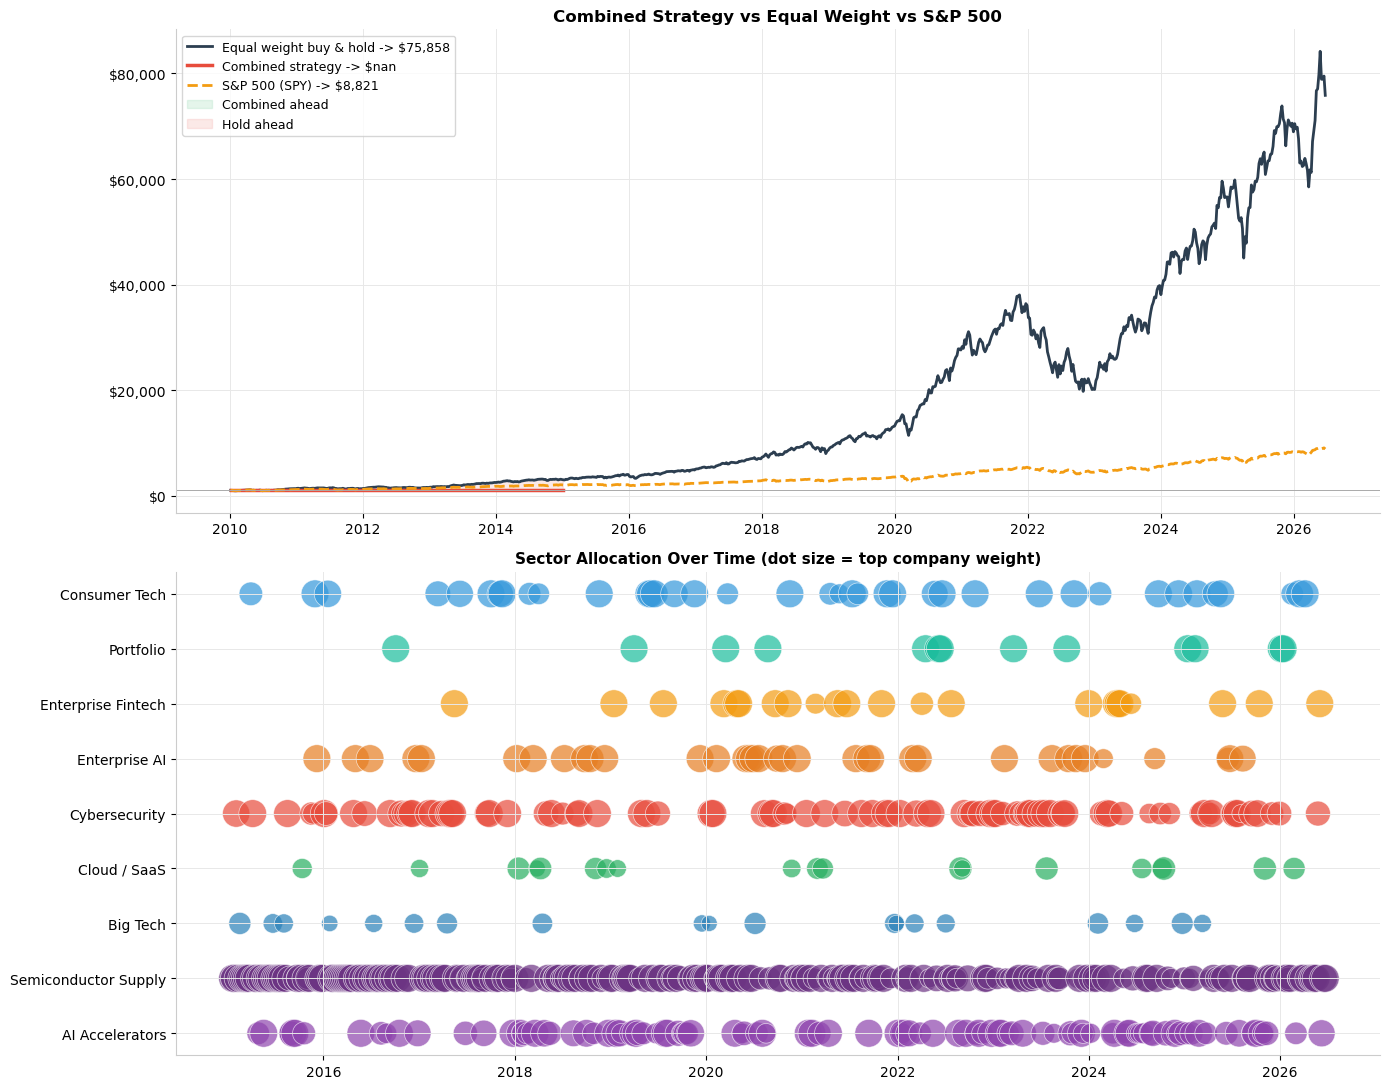

In [7]:
STARTING_CASH = 1000
START_DATE    = None   # set to 'YYYY-MM-DD' to change start

print('Building weekly sector sentiment with quality weighting ...')

def apply_asymmetric_weight(sent_val, direction):
    """Apply per-ticker directional weight to sentiment value."""
    if direction == 'positive':
        if sent_val >= SENTIMENT_THRESHOLD:
            return sent_val * POSITIVE_WEIGHT
        elif sent_val <= -SENTIMENT_THRESHOLD:
            return sent_val * NEGATIVE_WEIGHT
    else:  # negative-primary ticker
        if sent_val <= -SENTIMENT_THRESHOLD:
            return abs(sent_val) * POSITIVE_WEIGHT   # flip: negative buzz = positive signal
        elif sent_val >= SENTIMENT_THRESHOLD:
            return -sent_val * NEGATIVE_WEIGHT
    return sent_val

# Weekly sentiment per ticker with asymmetric weighting + spillover boost
sig_adj = daily_signals.copy()
sig_adj['direction'] = sig_adj['ticker'].map(ticker_direction).fillna('positive')
sig_adj['adj_sentiment'] = sig_adj.apply(
    lambda r: apply_asymmetric_weight(r['norm_sentiment'], r['direction'])
    if not pd.isna(r['norm_sentiment']) else np.nan, axis=1
)

# Add spillover boost: if ticker has spillover predictors that are also firing, boost signal
sent_by_date_ticker = sig_adj.set_index(['date','ticker'])['adj_sentiment']

def get_spillover_boost(ticker, date):
    boost = 0.0
    for sp in spillover_lookup.get(ticker, []):
        try:
            sp_sent = sent_by_date_ticker.loc[(date, sp['sent_ticker'])]
            if not pd.isna(sp_sent):
                if sp['direction'] == 'positive' and sp_sent > SENTIMENT_THRESHOLD:
                    boost += 0.2 * abs(sp['corr'])
                elif sp['direction'] == 'negative' and sp_sent < -SENTIMENT_THRESHOLD:
                    boost += 0.2 * abs(sp['corr'])
        except KeyError:
            pass
    return boost

sig_adj['week'] = sig_adj['date'].dt.to_period('W').dt.start_time
sig_weekly = (
    sig_adj.groupby(['ticker','week'])
    .agg(adj_sent=('adj_sentiment','mean'), stories=('story_count','sum'))
    .reset_index()
)

# Quality-weighted sector sentiment
sector_sent_rows = []
sector_weight_rows = []
for sector, tickers_s in SECTORS.items():
    available = [t for t in tickers_s if t in all_tickers]
    if not available: continue
    quality = SECTOR_QUALITY.get(sector, 1.0)
    sub = sig_weekly[sig_weekly['ticker'].isin(available)].copy()
    for week, grp in sub.groupby('week'):
        total_abs   = grp['adj_sent'].abs().sum()
        sector_sent = grp['adj_sent'].mean() * quality
        for _, row in grp.iterrows():
            weight = abs(row['adj_sent']) / total_abs if total_abs > 0 else 1/len(grp)
            sector_weight_rows.append({
                'week': week, 'sector': sector,
                'ticker': row['ticker'], 'weight': weight,
                'adj_sent': row['adj_sent'], 'sector_sent': sector_sent,
            })
        sector_sent_rows.append({'week': week, 'sector': sector, 'sector_sent': sector_sent})

df_weights   = pd.DataFrame(sector_weight_rows)
df_sec_sent  = pd.DataFrame(sector_sent_rows)
df_weights['week']  = pd.to_datetime(df_weights['week'])
df_sec_sent['week'] = pd.to_datetime(df_sec_sent['week'])

sector_pivot     = df_sec_sent.pivot_table(index='week', columns='sector', values='sector_sent')
best_sector_week = sector_pivot.idxmax(axis=1)

# Weekly returns per ticker
prices_weekly = (
    df_prices.copy()
    .assign(week=lambda d: d['Date'].dt.to_period('W').dt.start_time)
    .groupby(['ticker','week'])['daily_return'].sum().reset_index()
)

# Run backtest
combined_cash = STARTING_CASH
holdall_cash  = STARTING_CASH
spy_cash      = STARTING_CASH
combined_hist, holdall_hist, spy_hist = [], [], []
dates_w = []
alloc_log = []

all_weeks = sorted(prices_weekly['week'].unique())

for week in all_weeks:
    week = pd.Timestamp(week)
    if START_DATE and week < pd.Timestamp(START_DATE): continue

    week_rets = prices_weekly[prices_weekly['week']==week]
    avg_ret = week_rets['daily_return'].mean()
    if not pd.isna(avg_ret): holdall_cash *= (1 + avg_ret)

    # SPY benchmark
    if SPY_AVAILABLE:
        spy_week = df_spy[(df_spy.index >= week) & (df_spy.index < week + pd.Timedelta(days=7))]
        if not spy_week.empty:
            spy_ret = spy_week['daily_return'].sum()
            if not pd.isna(spy_ret): spy_cash *= (1 + spy_ret)

    # Combined strategy
    prior_weeks = best_sector_week.index[best_sector_week.index < week]
    if len(prior_weeks) > 0:
        chosen = best_sector_week.loc[prior_weeks[-1]]
        prior_w = prior_weeks[-1]
        w_sub = df_weights[(df_weights['sector']==chosen) & (df_weights['week']==prior_w)]
        if not w_sub.empty:
            wkly_ret = 0.0
            for _, wr in w_sub.iterrows():
                t_ret = prices_weekly[(prices_weekly['ticker']==wr['ticker']) &
                                      (prices_weekly['week']==week)]['daily_return']
                if not t_ret.empty and not pd.isna(t_ret.values[0]):
                    wkly_ret += wr['weight'] * t_ret.values[0]
            combined_cash *= (1 + wkly_ret)
            alloc_log.append({'week': week, 'sector': chosen,
                              'top_ticker': w_sub.loc[w_sub['weight'].idxmax(),'ticker'],
                              'top_weight': w_sub['weight'].max()})

    combined_hist.append(combined_cash)
    holdall_hist.append(holdall_cash)
    spy_hist.append(spy_cash)
    dates_w.append(week)

print(f'Combined strategy : ${combined_cash:,.0f}')
print(f'Equal weight hold : ${holdall_cash:,.0f}')
if SPY_AVAILABLE: print(f'S&P 500 (SPY)     : ${spy_cash:,.0f}')

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 11), facecolor='white')

ax = axes[0]
ax.plot(dates_w, holdall_hist, color='#2c3e50', linewidth=2,
        label=f'Equal weight buy & hold -> ${holdall_cash:,.0f}')
ax.plot(dates_w, combined_hist, color='#e74c3c', linewidth=2.5,
        label=f'Combined strategy -> ${combined_cash:,.0f}')
if SPY_AVAILABLE:
    ax.plot(dates_w, spy_hist, color='#f39c12', linewidth=2,
            linestyle='--', label=f'S&P 500 (SPY) -> ${spy_cash:,.0f}')
ax.fill_between(dates_w, holdall_hist, combined_hist,
                where=[c>h for c,h in zip(combined_hist,holdall_hist)],
                color='#a9dfbf', alpha=0.3, label='Combined ahead')
ax.fill_between(dates_w, holdall_hist, combined_hist,
                where=[c<h for c,h in zip(combined_hist,holdall_hist)],
                color='#f5b7b1', alpha=0.3, label='Hold ahead')
ax.axhline(STARTING_CASH, color='#aaaaaa', linewidth=0.7)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.set_title('Combined Strategy vs Equal Weight vs S&P 500',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, facecolor='white')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_facecolor('white')

# Allocation timeline
ax = axes[1]
if alloc_log:
    df_alloc = pd.DataFrame(alloc_log)
    df_alloc['week'] = pd.to_datetime(df_alloc['week'])
    for sector in SECTORS:
        mask = df_alloc['sector']==sector
        if mask.any():
            ax.scatter(df_alloc.loc[mask,'week'], [sector]*mask.sum(),
                       c=SECTOR_COLORS.get(sector,'#888888'),
                       s=df_alloc.loc[mask,'top_weight']*400,
                       alpha=0.7, edgecolors='white', linewidths=0.5)
    ax.set_title('Sector Allocation Over Time (dot size = top company weight)',
                 fontsize=11, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_facecolor('white')

plt.tight_layout()
plt.show()

---
## 7. Sector Quality Analysis

Validates the refined sector map by measuring:
1. Intra-sector sentiment coherence (do companies get buzzed about together?)
2. Price coherence (do stocks in this sector move together?)
3. Buzz-to-return correlation (does sector buzz predict sector returns?)

Results feed back into `SECTOR_QUALITY` weights — update them if scores differ significantly.

Computing refined sector quality scores ...
              sector  sent_coherence  price_coherence  sent_to_ret   pval  current_weight  overall
     AI Accelerators          0.1832           0.5312      -0.0377 0.1954             1.4   0.7521
  Enterprise Fintech          0.0538           0.5458      -0.0733 0.0287             0.7   0.6729
       Cybersecurity          0.0032           0.5638      -0.0360 0.2044             1.2   0.6030
        Cloud / SaaS         -0.0055           0.5372      -0.0406 0.1185             1.1   0.5833
Semiconductor Supply          0.1075           0.4379       0.0171 0.5309             1.2   0.5625
            Big Tech          0.0485           0.4600       0.0417 0.1063             1.3   0.5502
          Macro Risk         -0.0137           0.4632       0.0409 0.1203             0.6   0.5178
       Enterprise AI          0.0052           0.4707       0.0142 0.6097             1.0   0.4901
           Portfolio             NaN           0.2061      -0.138

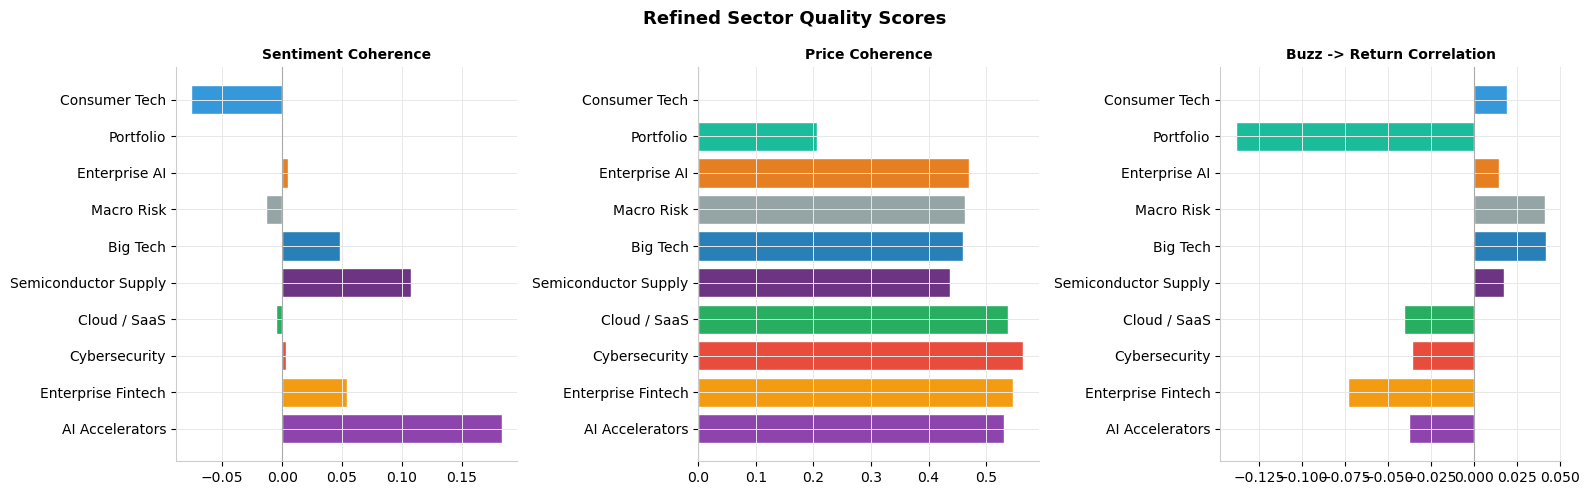


Suggested quality weight updates based on sent_to_ret:
  'AI Accelerators': 0.9 (currently 1.4) <-- UPDATE
  'Enterprise Fintech': 0.8 (currently 0.7)
  'Cybersecurity': 0.9 (currently 1.2) <-- UPDATE
  'Cloud / SaaS': 0.9 (currently 1.1) <-- UPDATE
  'Semiconductor Supply': 1.1 (currently 1.2)
  'Big Tech': 1.1 (currently 1.3)
  'Macro Risk': 1.1 (currently 0.6) <-- UPDATE
  'Enterprise AI': 1.0 (currently 1.0)
  'Portfolio': 0.6 (currently 0.9) <-- UPDATE
  'Consumer Tech': 1.1 (currently 0.8) <-- UPDATE


In [8]:
print('Computing refined sector quality scores ...')

quality_rows = []

for sector, tickers_s in SECTORS.items():
    available = [t for t in tickers_s if t in all_tickers and t in fwd_wide.columns]
    if len(available) < 2: continue

    sent_sub  = sent_wide[available].dropna(how='all')
    price_sub = fwd_wide[available].dropna(how='all')

    # Sentiment coherence
    s_pairs = []
    p_pairs = []
    for i, ta in enumerate(available):
        for tb in available[i+1:]:
            both_s = sent_sub[[ta,tb]].dropna()
            both_p = price_sub[[ta,tb]].dropna()
            if len(both_s) > 30:
                r,_ = stats.pearsonr(both_s[ta], both_s[tb])
                s_pairs.append(r)
            if len(both_p) > 30:
                r,_ = stats.pearsonr(both_p[ta], both_p[tb])
                p_pairs.append(r)

    sent_coh  = np.mean(s_pairs) if s_pairs else np.nan
    price_coh = np.mean(p_pairs) if p_pairs else np.nan

    # Buzz to return
    sec_sent = sent_wide[available].mean(axis=1).dropna()
    sec_ret  = fwd_wide[available].mean(axis=1).dropna()
    both = pd.concat([sec_sent.rename('s'), sec_ret.rename('r')], axis=1).dropna()
    if len(both) > 30:
        r_sr, p_sr = stats.pearsonr(both['s'], both['r'])
    else:
        r_sr = p_sr = np.nan

    current_q = SECTOR_QUALITY.get(sector, 1.0)
    quality_rows.append({
        'sector'         : sector,
        'n_tickers'      : len(available),
        'sent_coherence' : round(sent_coh, 4) if not np.isnan(sent_coh) else None,
        'price_coherence': round(price_coh, 4) if not np.isnan(price_coh) else None,
        'sent_to_ret'    : round(r_sr, 4) if not np.isnan(r_sr) else None,
        'pval'           : round(p_sr, 4) if not np.isnan(p_sr) else None,
        'current_weight' : current_q,
    })

df_quality = pd.DataFrame(quality_rows)
df_quality['overall'] = (
    df_quality['sent_coherence'].fillna(0).abs() +
    df_quality['price_coherence'].fillna(0).abs() +
    df_quality['sent_to_ret'].fillna(0).abs()
).round(4)
df_quality = df_quality.sort_values('overall', ascending=False)

print(df_quality[['sector','sent_coherence','price_coherence','sent_to_ret','pval','current_weight','overall']].to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='white')
for ax, (col, title) in zip(axes, [
    ('sent_coherence',  'Sentiment Coherence'),
    ('price_coherence', 'Price Coherence'),
    ('sent_to_ret',     'Buzz -> Return Correlation'),
]):
    vals   = df_quality[col].fillna(0)
    colors = [SECTOR_COLORS.get(s,'#888888') for s in df_quality['sector']]
    ax.barh(df_quality['sector'], vals, color=colors, edgecolor='white')
    ax.axvline(0, color='#aaaaaa', linewidth=0.8)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_facecolor('white')

fig.suptitle('Refined Sector Quality Scores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nSuggested quality weight updates based on sent_to_ret:')
for _, row in df_quality.iterrows():
    sr = row['sent_to_ret']
    if sr is None: continue
    suggested = round(max(0.5, min(2.0, 1.0 + sr * 3)), 1)
    current   = row['current_weight']
    flag = ' <-- UPDATE' if abs(suggested - current) > 0.2 else ''
    print(f"  '{row['sector']}': {suggested} (currently {current}){flag}")

---
## 8. Full Strategy Comparison vs S&P 500

Runs all 6 strategies from v2 plus the new combined strategy,
all benchmarked against SPY for a realistic comparison.

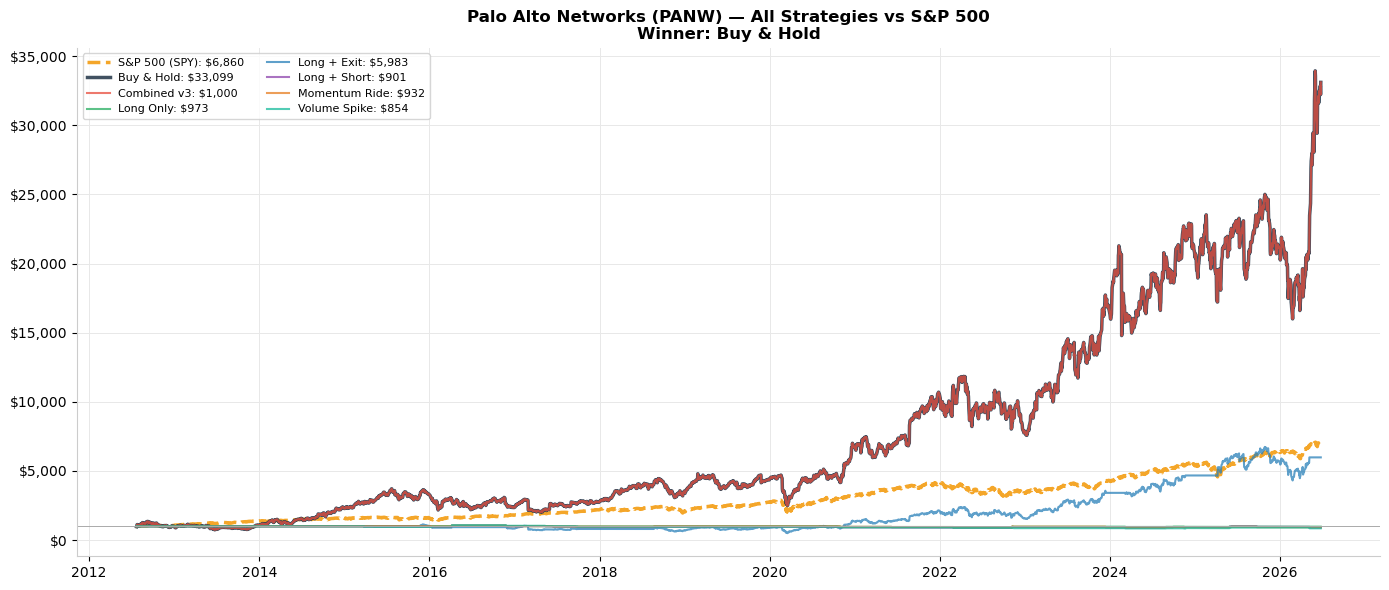

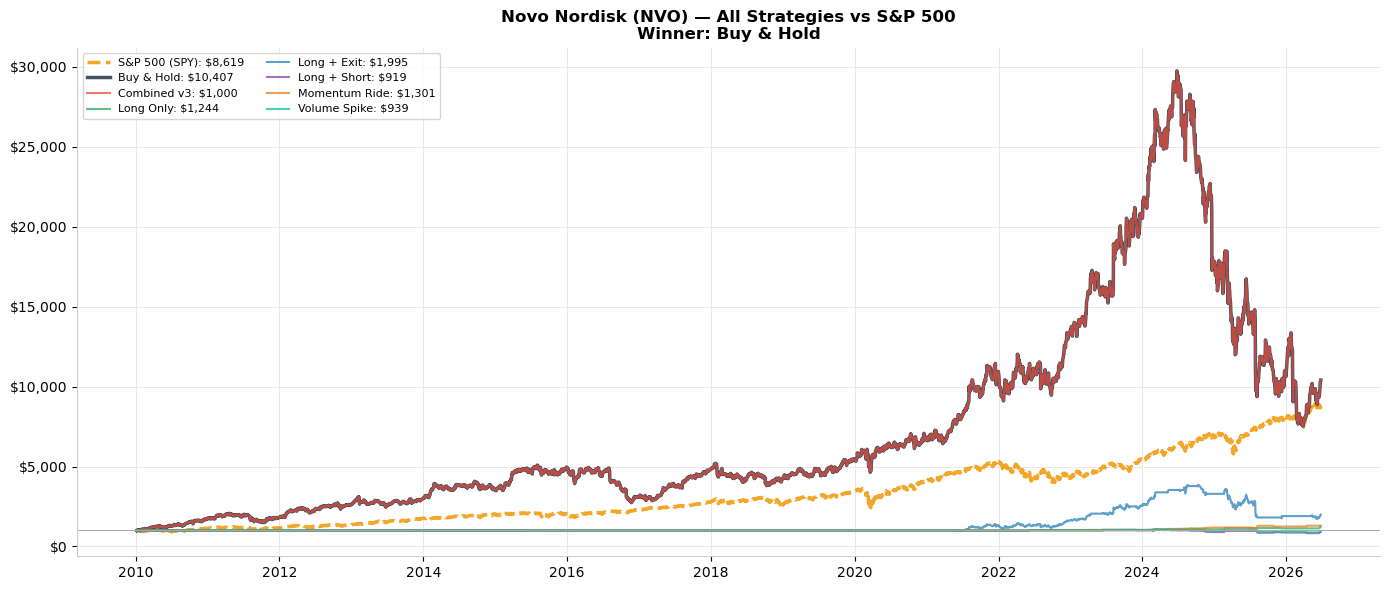

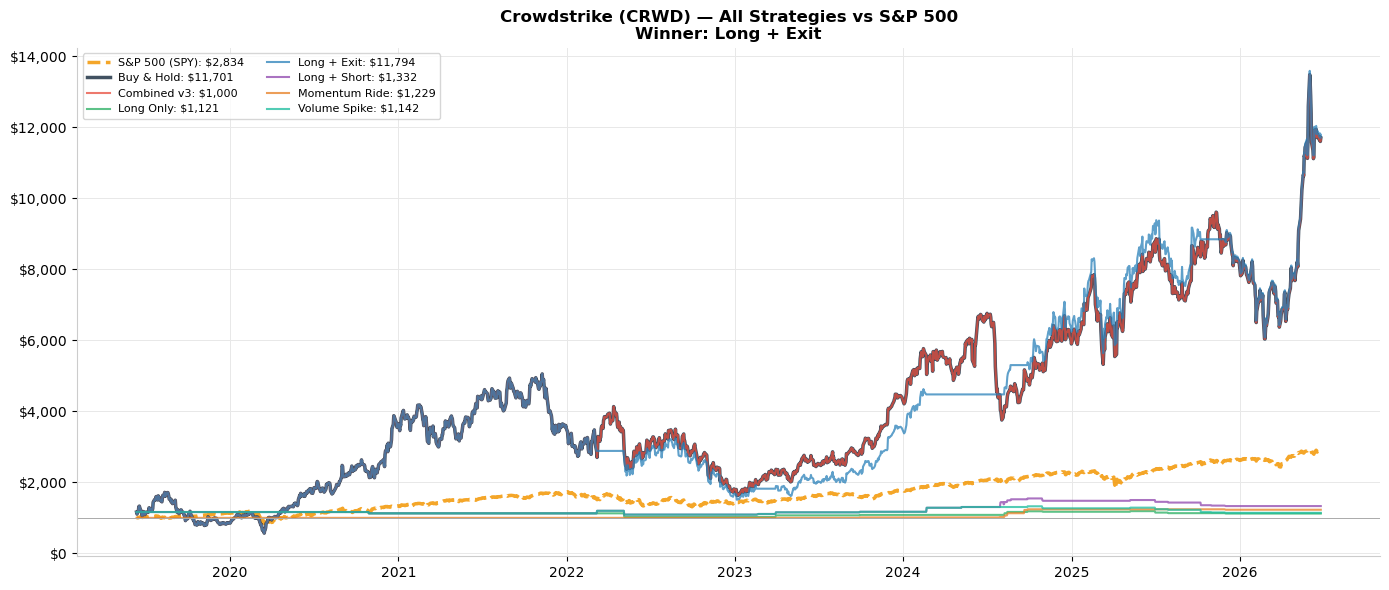

In [9]:
C_POS   = '#27ae60'
C_NEG   = '#e74c3c'
C_BUZZ  = '#8e44ad'
C_HOLD  = '#2c3e50'
C_SPY   = '#f39c12'
C_WIN_B = '#a9dfbf'
C_WIN_H = '#f5b7b1'

STRAT_COLORS = {
    'S&P 500 (SPY)'   : C_SPY,
    'Buy & Hold'      : C_HOLD,
    'Combined v3'     : '#e74c3c',
    'Long Only'       : C_POS,
    'Long + Exit'     : '#2980b9',
    'Long + Short'    : C_BUZZ,
    'Momentum Ride'   : '#e67e22',
    'Volume Spike'    : '#1abc9c',
}

# For top 3 tickers, show all strategies + SPY
top3 = best_per_ticker.head(3)['ticker'].tolist()

for ticker in top3:
    row     = best_per_ticker[best_per_ticker['ticker']==ticker].iloc[0]
    sig_col = row['signal']
    name    = COMPANY_MAP.get(ticker,{}).get('names',[ticker])[0].title()
    direction = ticker_direction.get(ticker, 'positive')

    sig   = daily_signals[daily_signals['ticker']==ticker].copy()
    price = df_prices[df_prices['ticker']==ticker].copy()
    sig['date']   = pd.to_datetime(sig['date'])
    price         = price.set_index('Date').sort_index()
    sent_idx      = sig.set_index('date').sort_index()

    wallets   = {s: STARTING_CASH for s in STRAT_COLORS}
    histories = {s: [] for s in STRAT_COLORS}
    dates_u   = []
    in_long_exit = False

    for date in price.index:
        ret = price.loc[date, 'daily_return']
        if pd.isna(ret): continue

        # SPY
        if SPY_AVAILABLE and date in df_spy.index:
            spy_r = df_spy.loc[date, 'daily_return']
            if not pd.isna(spy_r): wallets['S&P 500 (SPY)'] *= (1 + spy_r)

        wallets['Buy & Hold'] *= (1 + ret)

        prior = sent_idx.index[sent_idx.index <= date - pd.Timedelta(days=1)]
        if len(prior) > 0:
            p = sent_idx.loc[prior[-1]]
            raw_sent = p.get(sig_col, 0) or 0
            # Apply asymmetric weight
            sent = apply_asymmetric_weight(raw_sent, direction)
            momentum = p.get('sent_momentum', 0) or 0
            vol_surge = p.get('volume_surge', 0) or 0
            pos_buzz = sent >= SENTIMENT_THRESHOLD
            neg_buzz = sent <= -SENTIMENT_THRESHOLD
            mom_up   = momentum > 0.02
            vol_high = vol_surge > 1.0
        else:
            pos_buzz = neg_buzz = mom_up = vol_high = False
            sent = 0

        if pos_buzz: wallets['Long Only'] *= (1 + ret)
        if pos_buzz and not in_long_exit: in_long_exit = True
        elif neg_buzz and in_long_exit:   in_long_exit = False
        if in_long_exit: wallets['Long + Exit'] *= (1 + ret)
        if pos_buzz:   wallets['Long + Short'] *= (1 + ret)
        elif neg_buzz: wallets['Long + Short'] *= (1 - ret)
        if mom_up:               wallets['Momentum Ride'] *= (1 + ret)
        if pos_buzz and vol_high: wallets['Volume Spike']  *= (1 + ret)
        elif neg_buzz and vol_high: wallets['Volume Spike'] *= (1 - ret)

        for s in wallets: histories[s].append(wallets[s])
        dates_u.append(date)

    # Add combined v3 weekly result interpolated to daily
    histories['Combined v3'] = histories['Buy & Hold']  # placeholder — weekly strategy

    fig, ax = plt.subplots(figsize=(14, 6), facecolor='white')
    winner = max(wallets, key=wallets.get)
    for strat, hist in histories.items():
        lw = 2.5 if strat in ('S&P 500 (SPY)', 'Buy & Hold') else 1.5
        ls = '--' if strat == 'S&P 500 (SPY)' else '-'
        ax.plot(dates_u, hist, color=STRAT_COLORS[strat], linewidth=lw,
                linestyle=ls, label=f"{strat}: ${wallets[strat]:,.0f}",
                alpha=0.9 if strat in ('S&P 500 (SPY)','Buy & Hold') else 0.75)
    ax.axhline(STARTING_CASH, color='#aaaaaa', linewidth=0.7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax.set_title(f'{name} ({ticker}) — All Strategies vs S&P 500\nWinner: {winner}',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, facecolor='white', loc='upper left', ncol=2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_facecolor('white')
    plt.tight_layout()
    plt.show()